In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import sys
import os

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)

from data_creator import load_2D
df = load_2D().dropna() # load data from files


In [ ]:

#%pip install xgboost
#!brew install libomp

X = df[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]].dropna()

scale = StandardScaler()
scaled_X = scale.fit_transform(X)
y = (df["AD"]).dropna()
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 42)


In [6]:
# Train XGBoost Regressor
xgbr = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    objective='reg:squarederror',
    random_state=42
)
xgbr.fit(X_train, y_train)
y_pred = xgbr.predict(X_test)


In [8]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(" XGBoost Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

📈 XGBoost Results:
RMSE: 5.5421
MAE : 3.7647
R²  : 0.6153


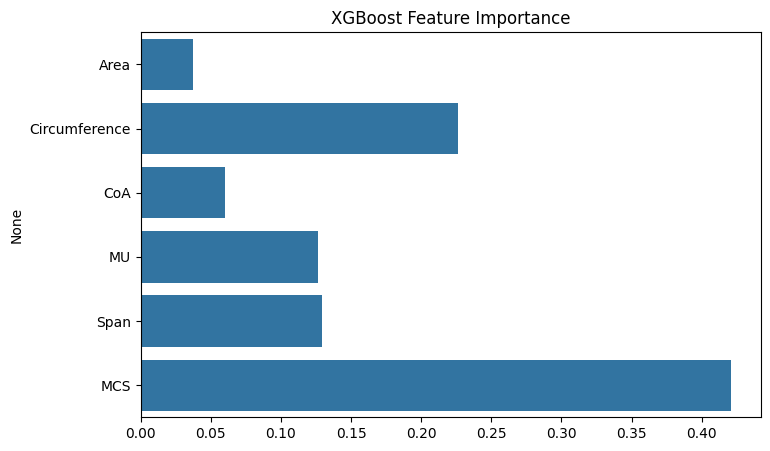

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_importance = pd.Series(xgbr.feature_importances_, index=X.columns)
plt.figure(figsize=(8,5))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title("XGBoost Feature Importance")
plt.show()